# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "pranav sathyababu"
student_id = "25588726"
group_id = "24"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [7]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [8]:
business_use_case_description = """
This project predicts the likelihood that a college or international basketball player will be drafted into the NBA based on performance, efficiency, and contextual attributes. The goal is to prioritize scouting resources, surface undervalued prospects earlier, and support data-driven draft decisions. By producing a ranked list with probabilities, the model helps front-office and scouting teams focus film study and workouts on the highest-upside players while quantifying risk.
"""


In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
stakeholders_expectations_explanations = """
The results will be used by team management, scouts, and analysts to support draft decisions by providing objective probabilities of a player being drafted. The primary users of these predictions are scouting departments, data analysts, and coaching staff who need to prioritize which athletes to evaluate more deeply. Accurate predictions help scouts allocate limited time and resources to players with the highest potential, while analysts and executives can integrate these insights into broader roster and salary planning. Indirectly, players are also impacted, as strong model outputs can influence which prospects receive greater exposure and opportunities during the draft process.
"""


In [11]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [12]:
train_df = pd.read_csv("../../data/raw/train.csv")
test_df  = pd.read_csv("../../data/raw/test.csv")


Explloring the training set

In [13]:
train_df.head()

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0


In [14]:
train_df.tail()

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
14769,Virginia,ACC,29,35.0,83.6,15.1,34.4,37.32,6.1,18.6,...,3.019260,0.7586,2.2069,2.9655,0.8276,0.6207,0.2069,2.4138,2678f4e0-cfa4-491a-88cb-2207f78e21f7,0.0
14770,SMU,CUSA,27,20.5,87.9,12.9,45.2,44.78,2.9,7.3,...,-0.557959,0.2222,0.5556,0.7778,0.3704,0.2963,0.0000,1.6296,45a8a388-7cf9-4ceb-a843-3b22875f6016,0.0
14771,Virginia,ACC,28,84.7,105.8,25.5,45.9,53.72,5.4,14.5,...,0.787983,1.6786,4.3571,6.0357,2.7857,1.0000,0.1071,16.5714,20a2285a-acb6-41f4-810b-9f4d92914ef3,0.0
14772,Arkansas Pine Bluff,SWAC,8,2.5,28.4,18.9,0.0,11.94,3.8,0.0,...,-4.730150,0.1000,0.0000,0.1000,0.2000,0.1000,0.0000,0.6000,1d19a682-2364-4874-abdc-0e340443b6c3,0.0
14773,South Carolina,SEC,11,2.7,86.7,13.6,33.3,36.70,3.1,13.8,...,1.035280,0.1667,0.6667,0.8333,0.0000,0.0833,0.0000,0.6667,484f5c19-1ff8-42c5-bddd-3615614c4c1b,0.0


In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 14774 non-null  object 
 1   conf                 14774 non-null  object 
 2   GP                   14774 non-null  int64  
 3   Min_per              14774 non-null  float64
 4   Ortg                 14774 non-null  float64
 5   usg                  14774 non-null  float64
 6   eFG                  14774 non-null  float64
 7   TS_per               14774 non-null  float64
 8   ORB_per              14774 non-null  float64
 9   DRB_per              14774 non-null  float64
 10  AST_per              14774 non-null  float64
 11  TO_per               14774 non-null  float64
 12  FTM                  14774 non-null  int64  
 13  FTA                  14774 non-null  int64  
 14  FT_per               14774 non-null  float64
 15  twoPM                14774 non-null 

In [16]:
train_df.describe(include='all')

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
count,14774,14774,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,...,14769.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14774,14774.000000
unique,355,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12155,NaN
top,Air Force,ACC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a1a06d07-12ae-4dfd-b295-011484a648d4,NaN
freq,72,652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
mean,NaN,NaN,21.251726,25.870123,85.771707,17.256674,41.507628,44.566821,5.644010,11.992744,...,-0.757406,0.552453,1.269347,1.821801,0.717322,0.368722,0.206213,3.662676,NaN,0.007987
std,NaN,NaN,10.517642,23.639878,34.164203,6.332899,20.610900,19.622173,15.097867,15.348129,...,3.773361,0.585068,1.125643,1.625416,0.897261,0.375689,0.343153,3.623175,NaN,0.089015
min,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-71.527600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,12.000000,4.200000,75.600000,13.900000,34.800000,38.820000,1.600000,7.500000,...,-2.138620,0.138900,0.428600,0.625000,0.125000,0.083300,0.000000,1.000000,NaN,0.000000
50%,NaN,NaN,25.000000,19.600000,91.300000,17.200000,44.900000,48.285000,4.200000,11.000000,...,-0.598833,0.381000,1.000000,1.400000,0.400000,0.259300,0.083300,2.448300,NaN,0.000000
75%,NaN,NaN,30.000000,42.900000,102.600000,20.600000,51.400000,54.090000,8.000000,15.100000,...,0.878493,0.764700,1.827600,2.551700,0.971400,0.545500,0.250000,5.363600,NaN,0.000000


In [17]:
train_df.shape

(14774, 62)

Exploring the Test Set

In [18]:
test_df.shape

(1297, 61)

In [19]:
test_df.head()

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id
0,UC Davis,BW,8,2.2,51.7,13.4,30.0,30.00,0.0,14.3,...,-11.240100,-4.721030,0.1000,0.6000,0.7000,0.2000,0.1000,0.0000,1.5000,c6d3ce49-28b6-4756-8061-b2bd68730c52
1,Campbell,BSth,25,16.4,85.0,25.2,50.0,52.10,2.0,11.8,...,-2.972020,-1.741870,0.1481,0.9259,1.0741,0.1481,0.4074,0.1111,4.0741,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5
2,Weber St.,BSky,29,50.5,117.8,16.8,61.8,59.77,12.3,17.1,...,0.739055,-0.259202,2.1562,2.7500,4.9062,0.7188,0.4062,1.0625,6.7500,0cf3e822-9446-4285-b7ed-7c19d8e976fe
3,Ohio,MAC,17,14.9,85.8,13.1,34.9,34.88,5.1,13.7,...,-3.339750,-0.573442,0.5789,1.5789,2.1579,0.5263,0.1579,0.1579,2.6842,b1a88de0-6852-4597-bb92-9164b40758e5
4,New Mexico St.,WAC,26,17.1,85.8,10.8,48.1,49.46,5.6,17.4,...,-4.184970,1.718210,0.4643,1.1429,1.6071,0.1071,0.0714,0.4286,1.7500,97c327ce-d051-40f0-9166-1a43557c3c92


In [20]:
test_df.describe(include='all')

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id
count,1297,1297,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,...,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297
unique,341,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1297
top,Georgia,SEC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c6d3ce49-28b6-4756-8061-b2bd68730c52
freq,9,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,NaN,19.982267,25.552814,84.709792,16.979337,41.696762,44.542768,4.930146,12.201234,...,-3.458307,-0.666449,0.530929,1.371215,1.902146,0.714865,0.380407,0.203022,3.800452,NaN
std,NaN,NaN,10.120440,23.540533,35.473332,6.516944,21.599565,20.612283,5.381617,8.722626,...,7.020922,3.294354,0.572363,1.153657,1.620209,0.828969,0.366184,0.320080,3.597651,NaN
min,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-42.288500,-20.362200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,10.000000,3.800000,76.200000,13.400000,35.300000,39.360000,1.100000,7.800000,...,-5.674170,-2.037690,0.142900,0.500000,0.727300,0.156200,0.095200,0.000000,1.136400,NaN
50%,NaN,NaN,23.000000,18.600000,90.000000,17.000000,45.400000,48.210000,3.500000,11.600000,...,-3.076930,-0.482479,0.366700,1.100000,1.521700,0.423100,0.277800,0.096800,2.666700,NaN
75%,NaN,NaN,29.000000,43.300000,102.400000,20.200000,52.000000,54.510000,7.400000,15.700000,...,-0.568284,1.009240,0.722200,1.935500,2.709700,1.000000,0.566700,0.266700,5.466700,NaN


In [21]:
# Check duplicates within train and test
print("Duplicates in train_df (rows):", train_df.duplicated().sum())
print("Duplicates in train_df (player_id):", train_df["player_id"].duplicated().sum())

print("Duplicates in test_df (rows):", test_df.duplicated().sum())
print("Duplicates in test_df (player_id):", test_df["player_id"].duplicated().sum())

# Check if any player_id appears in both train and test
train_ids = set(train_df["player_id"])
test_ids  = set(test_df["player_id"])

print("Overlap in player_id between train and test:", len(train_ids.intersection(test_ids)))


Duplicates in train_df (rows): 2462
Duplicates in train_df (player_id): 2619
Duplicates in test_df (rows): 0
Duplicates in test_df (player_id): 0
Overlap in player_id between train and test: 0


In [22]:
# Drop exact duplicate rows
train_df = train_df.drop_duplicates()

if "yr" in train_df.columns:
    train_df = (train_df.sort_values(["player_id", "yr"])
                          .groupby("player_id", as_index=False)
                          .tail(1))
else:
    proxy = next((c for c in ["adjoe", "pts", "bpm"] if c in train_df.columns), train_df.columns[0])
    train_df = (train_df.sort_values(["player_id", proxy])
                          .groupby("player_id", as_index=False)
                          .tail(1))

train_df = train_df.reset_index(drop=True)




### C.2 Define Target variable

The target variable is the binary indicator of whether a player is drafted (1) or not drafted (0) into the NBA.

In [23]:
# <Student to fill this section>
target_definition_explanations = """
The target variable is a binary indicator of whether a player is drafted (1) or not drafted (0). This definition directly reflects the business use case: the central decision-making problem for NBA teams is identifying which players are most likely to be drafted. By predicting this outcome, the model provides actionable probabilities that align with how teams allocate scouting resources and assess player value.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [25]:
target_name = 'drafted'


### C.4 Explore Target variable

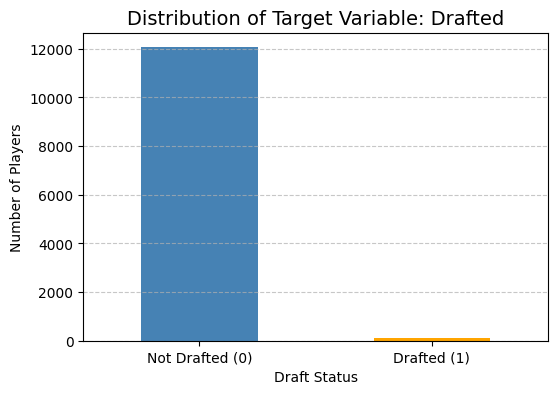

In [26]:
plt.figure(figsize=(6,4))
train_df['drafted'].value_counts().plot(kind='bar', color=['steelblue','orange'])
plt.title("Distribution of Target Variable: Drafted", fontsize=14)
plt.xticks([0,1], ['Not Drafted (0)', 'Drafted (1)'], rotation=0)
plt.ylabel("Number of Players")
plt.xlabel("Draft Status")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [27]:
# Group by drafted and compute descriptive stats for some key performance metrics
summary_stats = train_df.groupby('drafted')[['pts','ast','treb','bpm','mp']].mean().round(2)

# Check the year distribution by draft status
year_dist = train_df.groupby(['year','drafted']).size().unstack(fill_value=0)

# Check conference distribution for drafted players only (top 10)
conf_dist_drafted = train_df[train_df['drafted']==1]['conf'].value_counts().head(10)

summary = {
    "summary_stats_by_target": summary_stats.to_dict(),
    "year_distribution_sample": year_dist.head(10).to_dict(),
    "top_conferences_drafted": conf_dist_drafted.to_dict()
}
summary

{'summary_stats_by_target': {'pts': {0.0: 3.6, 1.0: 13.16},
  'ast': {0.0: 0.71, 1.0: 2.04},
  'treb': {0.0: 1.79, 1.0: 5.84},
  'bpm': {0.0: -4.16, 1.0: 6.53},
  'mp': {0.0: 12.19, 1.0: 27.93}},
 'year_distribution_sample': {0.0: {2009: 1262,
   2010: 1221,
   2011: 1168,
   2012: 1221,
   2013: 1166,
   2014: 1200,
   2015: 1164,
   2016: 1241,
   2017: 1197,
   2018: 1218},
  1.0: {2009: 4,
   2010: 10,
   2011: 6,
   2012: 8,
   2013: 7,
   2014: 9,
   2015: 12,
   2016: 13,
   2017: 14,
   2018: 14}},
 'top_conferences_drafted': {'SEC': 27,
  'ACC': 19,
  'B12': 16,
  'P12': 15,
  'BE': 6,
  'B10': 6,
  'P10': 2,
  'MWC': 2,
  'CUSA': 2,
  'A10': 1}}

In [28]:
# <Student to fill this section>
target_distribution_explanations = """
The target variable for this project is drafted, which indicates whether a college player was selected in the NBA draft (1 = drafted, 0 = not drafted). Its distribution is highly imbalanced, with only 0.8% drafted players compared to 99.2% not drafted, meaning accuracy alone is not a reliable evaluation metric. Drafted players typically show stronger performance — higher points, rebounds, assists, and minutes — and often come from major conferences, but the small sample size of drafted players and potential biases (conference visibility, missing stats, temporal effects) make prediction challenging.
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `pts`

In [30]:
# Summary statistics
pts_summary = train_df.groupby('drafted')['pts'].describe().round(2)
print("Summary stats for pts:\n", pts_summary)

Summary stats for pts:
            count   mean   std  min    25%    50%    75%    max
drafted                                                       
0.0      12057.0   3.60  3.51  0.0   1.00   2.45   5.27  23.70
1.0         97.0  13.16  4.33  3.0  10.33  12.94  15.97  27.38


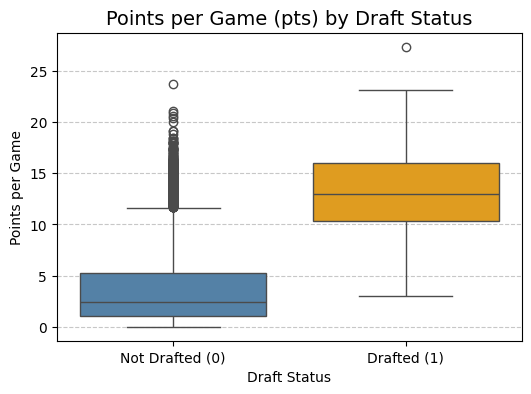

In [31]:
# Boxplot to show distribution
plt.figure(figsize=(6,4))
sns.boxplot(x='drafted', y='pts', data=train_df, palette=['steelblue','orange'])
plt.title("Points per Game (pts) by Draft Status", fontsize=14)
plt.xticks([0,1], ['Not Drafted (0)', 'Drafted (1)'])
plt.xlabel("Draft Status")
plt.ylabel("Points per Game")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [32]:
feature_1_insights = """
The feature `pts` (points per game) shows a clear gap between drafted and non-drafted players. 
Drafted players average about 13 points, compared to only 3.6 for non-drafted. 
This confirms that scoring ability is a strong predictor of draft likelihood, though it should not be used alone, 
as some players are drafted for defense, efficiency, or physical traits. 
"""


In [33]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `mp`

In [34]:
# Summary statistics
mp_summary = train_df.groupby('drafted')['mp'].describe().round(2)
print("Summary stats for mp:\n", mp_summary)

Summary stats for mp:
            count   mean   std   min    25%    50%    75%    max
drafted                                                        
0.0      12057.0  12.19  8.88  0.00   4.65  10.26  18.33  50.00
1.0         97.0  27.93  6.11  7.48  24.44  29.50  32.40  35.87


<Figure size 600x400 with 0 Axes>

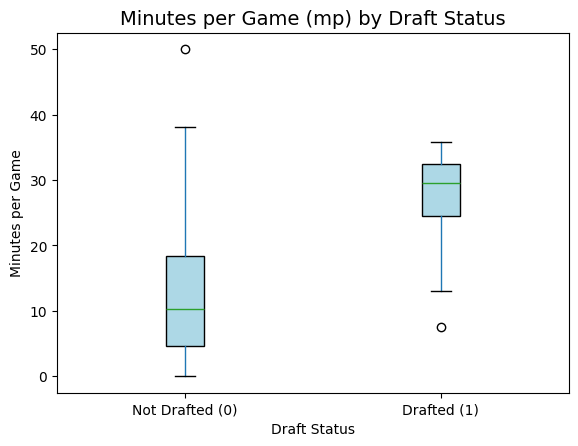

In [35]:
# Boxplot with matplotlib
plt.figure(figsize=(6,4))
train_df.boxplot(column='mp', by='drafted', grid=False, patch_artist=True,
                 boxprops=dict(facecolor="lightblue"))
plt.title("Minutes per Game (mp) by Draft Status", fontsize=14)
plt.suptitle("")  # remove automatic title
plt.xticks([1,2], ['Not Drafted (0)', 'Drafted (1)'])
plt.xlabel("Draft Status")
plt.ylabel("Minutes per Game")
plt.show()

In [36]:
feature_2_insights = """
The feature `mp` (minutes per game) shows drafted players averaging about 28 minutes, 
while non-drafted players average only 12. This reflects greater playing time and 
trust from coaches for future NBA prospects. While useful, minutes can also be influenced 
by team depth or role, so it should be combined with performance and efficiency metrics 
for stronger predictive power.
"""


In [37]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest `bpm`


In [38]:
# Summary statistics
bpm_summary = train_df.groupby('drafted')['bpm'].describe().round(2)
print("Summary stats for bpm:\n", bpm_summary)

Summary stats for bpm:
            count  mean   std    min   25%   50%   75%     max
drafted                                                      
0.0      12054.0 -4.16  9.84 -88.48 -7.10 -3.46 -0.19  685.31
1.0         97.0  6.53  3.45  -4.93  4.21  6.83  8.70   17.67


<Figure size 600x400 with 0 Axes>

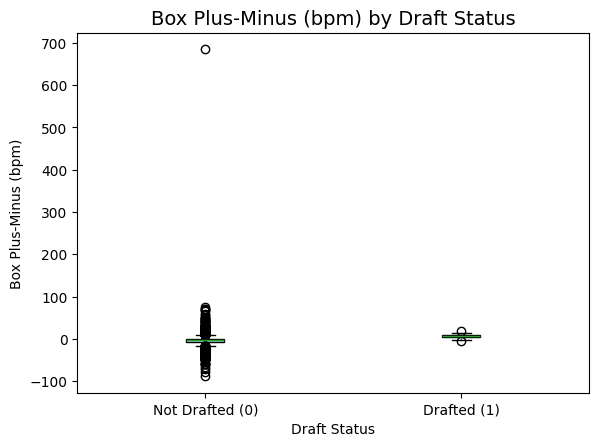

In [39]:
# Boxplot with matplotlib
plt.figure(figsize=(6,4))
train_df.boxplot(column='bpm', by='drafted', grid=False, patch_artist=True,
                 boxprops=dict(facecolor="lightblue"))
plt.title("Box Plus-Minus (bpm) by Draft Status", fontsize=14)
plt.suptitle("")  # remove automatic title
plt.xticks([1,2], ['Not Drafted (0)', 'Drafted (1)'])
plt.xlabel("Draft Status")
plt.ylabel("Box Plus-Minus (bpm)")
plt.show()

In [40]:
feature_3_insights = """
The feature `bpm` (Box Plus-Minus) highlights a sharp separation between drafted and non-drafted players. 
Drafted players average around +6.6, indicating strong positive impact, while non-drafted players average -4.2, 
suggesting below-average performance. This makes bpm one of the most discriminative features for draft prediction, 
though it is an advanced stat and may already combine information from multiple other metrics.
"""


In [41]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_3_insights)

### C.7 Explore Feature of Interest `TS_per`

> You can add more cells related to other feeatures in this section

In [42]:
# Summary statistics
ts_summary = train_df.groupby('drafted')['TS_per'].describe().round(2)
print("Summary stats for TS_per:\n", ts_summary)

Summary stats for TS_per:
            count   mean    std    min    25%    50%    75%     max
drafted                                                           
0.0      12058.0  44.58  19.53   0.00  38.86  48.24  53.99  150.00
1.0         97.0  56.70   5.04  43.76  53.51  56.56  59.10   70.32


<Figure size 600x400 with 0 Axes>

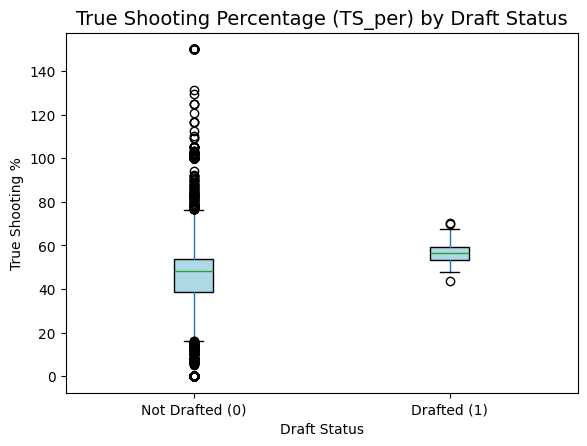

In [43]:
# Boxplot with matplotlib
plt.figure(figsize=(6,4))
train_df.boxplot(column='TS_per', by='drafted', grid=False, patch_artist=True,
                 boxprops=dict(facecolor="lightblue"))
plt.title("True Shooting Percentage (TS_per) by Draft Status", fontsize=14)
plt.suptitle("")  # remove automatic title
plt.xticks([1,2], ['Not Drafted (0)', 'Drafted (1)'])
plt.xlabel("Draft Status")
plt.ylabel("True Shooting %")
plt.show()

In [44]:
feature_4_insights = """
The feature `TS_per` (True Shooting %) shows that drafted players are generally more efficient scorers. 
Their average TS% is noticeably higher than non-drafted players, reflecting better shot selection and 
free-throw/3-point efficiency. This aligns with modern NBA priorities, where efficiency is valued 
alongside scoring volume. However, efficiency can sometimes favor role players who take fewer shots, 
so it should be interpreted together with usage and minutes.
"""


In [45]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_4_insights)

---
## D. Feature Selection


### D.1 Approach "Random Forest"


Top 15 Numeric Features by Importance:
Rec_Rank    0.162848
porpag      0.102734
dporpag     0.085060
gbpm        0.060216
twoPM       0.058972
pts         0.055261
adjoe       0.052960
bpm         0.039050
FTA         0.038565
twoPA       0.036715
dreb        0.027888
ogbpm       0.026054
stops       0.023879
adrtg       0.022436
rimmade     0.021423
dtype: float64


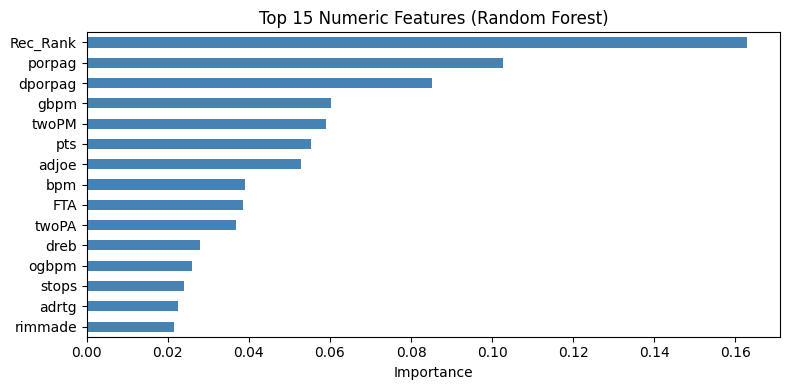

In [46]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1) Define features and target
X = train_df.drop(columns=['drafted','player_id','team'])
y = train_df['drafted']

# 2) Select numeric features only
num_cols = X.select_dtypes(include=[np.number]).columns
X_num = X[num_cols].fillna(0)

# 3) Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_num, y)

# 4) Get feature importances
num_importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False)

# Show top 15
print("Top 15 Numeric Features by Importance:")
print(num_importances.head(15))

# 5) Plot bar chart
plt.figure(figsize=(8,4))
num_importances.head(15)[::-1].plot(kind='barh', color='steelblue')
plt.title("Top 15 Numeric Features (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [47]:
feature_selection_1_insights = """
For feature selection, I applied Random Forest feature importance to the numeric variables. 
This method was chosen because Random Forest can naturally handle high-dimensional numeric data 
and capture non-linear relationships without requiring scaling or transformations. 

The results showed that advanced performance metrics such as `Rec_Rank`, `porpag`, `dporpag`, and `bpm` 
were among the strongest predictors of draft status, while traditional stats like `pts`, `FTA`, and `twoPM` 
also contributed meaningfully. This indicates that both advanced impact measures and raw box score 
statistics play an important role in distinguishing drafted from non-drafted players.
"""


In [48]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Chi-Square Test"


Categorical Features Ranked by Chi-Square Test:
  Feature       Chi2   p-value
0    conf  10.169938  0.001427
2      ht   6.768835  0.009276
1      yr        NaN       NaN
3    type        NaN       NaN


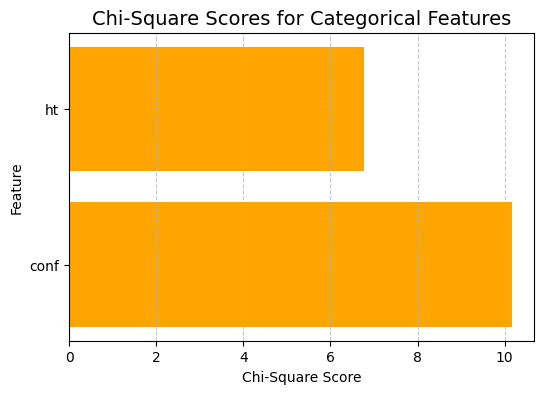

In [49]:
import pandas as pd
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

# 1) Define features and target
X = train_df.drop(columns=['drafted','player_id','team'])
y = train_df['drafted']

# 2) Select categorical columns
cat_cols = X.select_dtypes(exclude=['number']).columns
X_cat = X[cat_cols].copy()

# 3) Encode categories numerically 
enc = LabelEncoder()
X_cat_encoded = X_cat.apply(lambda col: enc.fit_transform(col.astype(str)))

# 4) Run Chi-Square test
chi_scores, p_vals = chi2(X_cat_encoded, y)

# 5) Collect results
cat_results = pd.DataFrame({
    "Feature": cat_cols,
    "Chi2": chi_scores,
    "p-value": p_vals
}).sort_values("Chi2", ascending=False)

print("Categorical Features Ranked by Chi-Square Test:")
print(cat_results)

# Drop NaN rows before plotting
cat_results_clean = cat_results.dropna(subset=["Chi2"])

plt.figure(figsize=(6,4))
plt.barh(cat_results_clean["Feature"], cat_results_clean["Chi2"], color="orange")
plt.title("Chi-Square Scores for Categorical Features", fontsize=14)
plt.xlabel("Chi-Square Score")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [50]:
feature_selection_2_insights = """
For categorical features, I applied the Chi-Square test to measure their association with the 
binary target `drafted`. This test is suitable for categorical predictors because it evaluates 
the statistical dependence between categories and outcomes. 

The results showed that both `conf` (conference) and `ht` (player height) were significantly 
associated with draft status. This reflects real-world dynamics, where players from major 
conferences and those with greater size have higher chances of being drafted. On the other hand, 
`yr` (year in college) and `type` did not provide useful signal, and `team`/`player_id` were 
excluded as identifiers. These findings confirm that contextual and physical attributes, 
in addition to performance metrics, matter in draft predictions.
"""



In [51]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features

In [52]:
features_list = [
    # Numeric features (Random Forest)
    'Rec_Rank', 'porpag', 'dporpag', 'bpm', 'gbpm', 'ogbpm',
    'adjoe', 'twoPM', 'twoPA', 'FTA', 'pts', 'stops', 'dreb', 'rimmade',

    # Categorical features (Chi-Square)
    'conf', 'ht',
    #target
    'drafted'
]


In [53]:
# <Student to fill this section>
feature_selection_explanations = """
The final feature list combines advanced efficiency and impact metrics, traditional box score 
statistics, and key contextual attributes. From the numeric side, features such as `Rec_Rank`, 
`porpag`, `dporpag`, `bpm`, and `adjoe` capture a player's overall value, while `pts`, `twoPM`, 
`twoPA`, `FTA`, and `dreb` reflect traditional production. Defensive and finishing ability are 
represented by `stops` and `rimmade`. 

From the categorical side, `conf` highlights exposure in stronger conferences, and `ht` provides 
a measure of physical size, which is crucial in draft decisions. Together, these features offer 
a balanced mix of production, efficiency, defense, physicality, and context, aligning closely with 
the factors that influence NBA draft outcomes.
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation


## E0. Data Cleaning

In [55]:
train_df_clean = train_df[features_list].copy()
test_df_clean = test_df[[col for col in features_list if col != "drafted"]].copy()

In [56]:
# Check missing values in the dataset
missing_summary = train_df_clean.isna().sum().sort_values(ascending=False)

# Display top 20 features with most missing values
print("Missing Values Summary (Top 20):")
print(missing_summary.head(20))

# Show percentage of missing values
missing_percent = (train_df_clean.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing Values Percentage (Top 20):")
print(missing_percent.head(20))


Missing Values Summary (Top 20):
Rec_Rank    8146
rimmade     1681
ht             7
dporpag        4
bpm            4
gbpm           4
stops          4
ogbpm          4
pts            1
dreb           1
twoPM          0
adjoe          0
porpag         0
twoPA          0
FTA            0
conf           0
drafted        0
dtype: int64

Missing Values Percentage (Top 20):
Rec_Rank    67.017688
rimmade     13.829700
ht           0.057589
dporpag      0.032908
bpm          0.032908
gbpm         0.032908
stops        0.032908
ogbpm        0.032908
pts          0.008227
dreb         0.008227
twoPM        0.000000
adjoe        0.000000
porpag       0.000000
twoPA        0.000000
FTA          0.000000
conf         0.000000
drafted      0.000000
dtype: float64


In [57]:
# Check missing values in the test dataset
missing_summary_test = test_df_clean.isna().sum().sort_values(ascending=False)

print("Missing Values Summary (Top 20):")
print(missing_summary_test.head(20))

# Show percentage of missing values
missing_percent_test = (test_df_clean.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing Values Percentage (Top 20):")
print(missing_percent_test.head(20))


Missing Values Summary (Top 20):
Rec_Rank    894
rimmade      61
ht            6
porpag        0
gbpm          0
ogbpm         0
dporpag       0
bpm           0
twoPM         0
adjoe         0
twoPA         0
FTA           0
stops         0
pts           0
dreb          0
conf          0
dtype: int64

Missing Values Percentage (Top 20):
Rec_Rank    68.928296
rimmade      4.703161
ht           0.462606
porpag       0.000000
gbpm         0.000000
ogbpm        0.000000
dporpag      0.000000
bpm          0.000000
twoPM        0.000000
adjoe        0.000000
twoPA        0.000000
FTA          0.000000
stops        0.000000
pts          0.000000
dreb         0.000000
conf         0.000000
dtype: float64


In [58]:
train_df_clean = train_df_clean.drop(columns=["Rec_Rank", "rimmade"], errors="ignore")

In [59]:
test_df_clean = test_df_clean.drop(columns=["Rec_Rank", "rimmade"], errors="ignore")

In [60]:
test_df_clean

,porpag,dporpag,bpm,gbpm,ogbpm,adjoe,twoPM,twoPA,FTA,pts,stops,dreb,conf,ht
0,-0.467719,0.183334,-11.46420,-15.961100,-11.240100,45.4034,0,2,0,1.5000,3.936000,0.6000,BW,6-Jun
1,0.005042,0.628558,-7.17468,-4.713890,-2.972020,85.5322,14,23,12,4.0741,35.018700,0.9259,BSth,5-Jun
2,1.887280,1.536980,1.87823,0.479853,0.739055,112.2590,81,131,43,6.7500,111.992000,2.7500,BSky,9-Jun
3,-0.311827,0.905079,-3.14433,-3.913200,-3.339750,76.8065,6,13,0,2.6842,30.525500,1.5789,MAC,7-Jun
4,-0.343108,0.778716,-1.63445,-2.466760,-4.184970,72.3601,13,27,7,1.7500,34.918500,1.1429,WAC,10-Jun
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,-0.537854,0.206915,-7.21264,-13.087300,-11.448500,25.7252,0,3,2,0.1000,5.141130,0.1000,BSky,Jun-00
1293,-0.338843,0.043969,-40.64580,-39.545900,-23.654600,-12.3082,0,2,0,0.0000,0.305793,0.0000,OVC,NaN
1294,-0.414715,0.046150,-55.56530,-39.908400,-22.468800,-34.1733,0,1,0,0.0000,0.088249,0.0000,MAAC,11-May
1295,-0.685731,0.774465,-24.68950,-16.613300,-13.372700,57.1100,0,0,4,2.0000,1.156220,1.0000,SWAC,Jun-00


In [61]:
train_df_clean = train_df_clean.dropna(subset=["ht", "dporpag", "ogbpm", "gbpm", "stops", "bpm", "pts", "dreb"])

In [62]:
missing_summary = train_df_clean.isna().sum().sort_values(ascending=False)

# Display top 20 features with most missing values
print("Missing Values Summary (Top 20):")
print(missing_summary.head(20))

Missing Values Summary (Top 20):
porpag     0
dporpag    0
bpm        0
gbpm       0
ogbpm      0
adjoe      0
twoPM      0
twoPA      0
FTA        0
pts        0
stops      0
dreb       0
conf       0
ht         0
drafted    0
dtype: int64


In [63]:
missing_summary = test_df_clean.isna().sum().sort_values(ascending=False)

# Display top 20 features with most missing values
print("Missing Values Summary (Top 20):")
print(missing_summary.head(20))

Missing Values Summary (Top 20):
ht         6
porpag     0
bpm        0
gbpm       0
ogbpm      0
dporpag    0
adjoe      0
twoPM      0
FTA        0
twoPA      0
pts        0
stops      0
dreb       0
conf       0
dtype: int64


### E.1 Data Transformation label encoder for conf

In [64]:
train_df_trans = train_df_clean.copy()
test_df_trans = test_df_clean.copy()

In [65]:
le = LabelEncoder()
train_df_trans['conf'] = le.fit_transform(train_df_trans['conf'].astype(str))
test_df_trans['conf'] = le.fit_transform(test_df_trans['conf'].astype(str))

In [66]:
test_df_trans

,porpag,dporpag,bpm,gbpm,ogbpm,adjoe,twoPM,twoPA,FTA,pts,stops,dreb,conf,ht
0,-0.467719,0.183334,-11.46420,-15.961100,-11.240100,45.4034,0,2,0,1.5000,3.936000,0.6000,10,6-Jun
1,0.005042,0.628558,-7.17468,-4.713890,-2.972020,85.5322,14,23,12,4.0741,35.018700,0.9259,9,5-Jun
2,1.887280,1.536980,1.87823,0.479853,0.739055,112.2590,81,131,43,6.7500,111.992000,2.7500,8,9-Jun
3,-0.311827,0.905079,-3.14433,-3.913200,-3.339750,76.8065,6,13,0,2.6842,30.525500,1.5789,16,7-Jun
4,-0.343108,0.778716,-1.63445,-2.466760,-4.184970,72.3601,13,27,7,1.7500,34.918500,1.1429,30,10-Jun
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,-0.537854,0.206915,-7.21264,-13.087300,-11.448500,25.7252,0,3,2,0.1000,5.141130,0.1000,8,Jun-00
1293,-0.338843,0.043969,-40.64580,-39.545900,-23.654600,-12.3082,0,2,0,0.0000,0.305793,0.0000,21,NaN
1294,-0.414715,0.046150,-55.56530,-39.908400,-22.468800,-34.1733,0,1,0,0.0000,0.088249,0.0000,15,11-May
1295,-0.685731,0.774465,-24.68950,-16.613300,-13.372700,57.1100,0,0,4,2.0000,1.156220,1.0000,27,Jun-00


In [67]:
# <Student to fill this section>
data_cleaning_1_explanations = """
The 'conf' column was label encoded to convert conference names into numerical values. 
This step is important because most machine learning models cannot handle string inputs directly. 
Encoding ensures the model can incorporate conference information, which is a key contextual factor 
influencing draft outcomes.
"""

In [68]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation - Correct mapping for 'ht'

In [69]:
unique_ht_values = train_df_trans['ht'].dropna().unique()
unique_ht_values_sorted = sorted(unique_ht_values.astype(str))

unique_ht_values_sorted[:100]

[np.str_('-'),
 np.str_('0'),
 np.str_('1-Jul'),
 np.str_('1-Jun'),
 np.str_('1-May'),
 np.str_('10-Jun'),
 np.str_('10-May'),
 np.str_('11-Jun'),
 np.str_('11-May'),
 np.str_('2-Jul'),
 np.str_('2-Jun'),
 np.str_('2-May'),
 np.str_('3-Jul'),
 np.str_('3-Jun'),
 np.str_('4-Jul'),
 np.str_('4-Jun'),
 np.str_('5-Apr'),
 np.str_('5-Jul'),
 np.str_('5-Jun'),
 np.str_('5-May'),
 np.str_('6-Jul'),
 np.str_('6-Jun'),
 np.str_('6-May'),
 np.str_('7-Jun'),
 np.str_('7-May'),
 np.str_('8-Jun'),
 np.str_('8-May'),
 np.str_('9-Jun'),
 np.str_('9-May'),
 np.str_('Apr-00'),
 np.str_('Jul-00'),
 np.str_('Jun-00')]

In [70]:
import numpy as np

def convert_ht_to_inches(val):
    """Convert corrupted ht strings like '11-May' into total inches."""
    if pd.isna(val) or val in ["-", "0", ""]:
        return np.nan
    
    month_map = {   "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "Jun": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12}
    
    try:
        day, month = val.split("-")
        feet = month_map.get(month[:3].title(), None)
        if feet is None:
            return np.nan
        inches = int(day)
        return feet * 12 + inches  # total inches
    except:
        return np.nan

# Overwrite ht with cleaned inches
train_df_trans['ht'] = train_df_trans['ht'].apply(convert_ht_to_inches)
test_df_trans['ht'] = test_df_trans['ht'].apply(convert_ht_to_inches)

# Check results
print(train_df_trans['ht'].describe())
print(train_df_trans[['ht']].head(20))

# Check results
print(test_df_trans['ht'].describe())
print(test_df_trans[['ht']].head(20))


count    11259.000000
mean        76.877343
std          3.409563
min         53.000000
25%         75.000000
50%         77.000000
75%         79.000000
max         90.000000
Name: ht, dtype: float64
      ht
0   73.0
1   75.0
2   77.0
3   74.0
4   79.0
5   73.0
6   73.0
7   76.0
8   76.0
9    NaN
10  79.0
11  83.0
12   NaN
13  76.0
14  77.0
15  77.0
16  75.0
17  77.0
18  78.0
19  75.0
count    1211.000000
mean       77.161850
std         3.222375
min        67.000000
25%        75.000000
50%        77.000000
75%        79.000000
max        88.000000
Name: ht, dtype: float64
      ht
0   78.0
1   77.0
2   81.0
3   79.0
4   82.0
5   77.0
6   82.0
7   76.0
8   79.0
9   82.0
10  80.0
11  76.0
12  79.0
13  83.0
14  80.0
15  82.0
16  81.0
17  77.0
18  76.0
19  77.0


In [71]:
train_df_trans['ht'].value_counts(dropna=False)


ht
76.0    1177
80.0    1154
77.0    1152
79.0    1148
75.0    1136
78.0    1077
74.0    1049
NaN      885
81.0     837
73.0     789
82.0     513
71.0     376
70.0     314
83.0     234
69.0     136
68.0      58
85.0      41
67.0      23
86.0      20
87.0       9
66.0       6
65.0       2
90.0       2
88.0       2
53.0       1
89.0       1
61.0       1
62.0       1
Name: count, dtype: int64

In [72]:
test_df_trans['ht'].value_counts(dropna=False)

ht
77.0    141
79.0    140
78.0    132
75.0    132
76.0    126
74.0     97
81.0     93
80.0     91
73.0     89
NaN      86
82.0     66
83.0     33
71.0     27
70.0     19
69.0      9
68.0      5
85.0      5
88.0      2
86.0      2
67.0      2
Name: count, dtype: int64

In [73]:
# Check missing values in the dataset
missing_summary = train_df_trans.isna().sum().sort_values(ascending=False)

# Display top 20 features with most missing values
print("Missing Values Summary (Top 20):")
print(missing_summary.head(20))


Missing Values Summary (Top 20):
ht         885
dporpag      0
porpag       0
gbpm         0
ogbpm        0
adjoe        0
bpm          0
twoPM        0
twoPA        0
pts          0
FTA          0
stops        0
dreb         0
conf         0
drafted      0
dtype: int64


In [74]:
import numpy as np
import pandas as pd


conf_medians = train_df_trans.groupby('conf')['ht'].median()
global_median = train_df_trans['ht'].median()

train_df_trans['ht_impute'] = train_df_trans['conf'].map(conf_medians)

train_df_trans['ht_impute'] = train_df_trans['ht_impute'].fillna(global_median)

train_df_trans['ht'] = train_df_trans['ht'].fillna(train_df_trans['ht_impute'])

train_df_trans = train_df_trans.drop(columns=['ht_impute'])

print("Remaining missing in ht:", train_df_trans['ht'].isna().sum())
print(train_df_trans['ht'].describe())


Remaining missing in ht: 0
count    12144.000000
mean        76.884552
std          3.287685
min         53.000000
25%         75.000000
50%         77.000000
75%         79.000000
max         90.000000
Name: ht, dtype: float64


In [75]:
# Use train medians
conf_medians = train_df_trans.groupby('conf')['ht'].median()
global_median = train_df_trans['ht'].median()

# Impute test_df_trans 'ht' the same way
test_df_trans['ht_impute'] = test_df_trans['conf'].map(conf_medians)
test_df_trans['ht_impute'] = test_df_trans['ht_impute'].fillna(global_median)
test_df_trans['ht'] = test_df_trans['ht'].fillna(test_df_trans['ht_impute'])
test_df_trans.drop(columns=['ht_impute'], inplace=True, errors='ignore')

# Quick check
print("Remaining missing in ht (test):", test_df_trans['ht'].isna().sum())
print(test_df_trans['ht'].describe())


Remaining missing in ht (test): 0
count    1297.000000
mean       77.154202
std         3.124865
min        67.000000
25%        75.000000
50%        77.000000
75%        79.000000
max        88.000000
Name: ht, dtype: float64


In [76]:
data_cleaning_2_explanations = """
The height column contained corrupted string values such as '11-May' that were incorrectly 
recorded instead of a standard feet-and-inches format. Cleaning and converting these values into 
a consistent numeric representation (total inches) is critical because height is a key predictor 
of draft outcomes in basketball. Leaving the corrupted values would introduce noise, reduce the 
accuracy of the models, and potentially bias results against players whose height data was not 
properly formatted. By standardizing height into a uniform numerical scale, we ensure that the 
feature is meaningful, comparable across players, and can be effectively used by statistical and 
machine learning models to capture the relationship between physical attributes and draft 
probability.
"""

In [77]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

---
## F. Feature Engineering

### F.1 New Feature "fta_per_pt"


In [78]:
train_df_trans['fta_per_pt'] = train_df_trans['FTA'] / (train_df_trans['pts'] + 1e-6)
test_df_trans['fta_per_pt'] = test_df_trans['FTA'] / (test_df_trans['pts'] + 1e-6)

In [79]:
# <Student to fill this section>
feature_engineering_1_explanations = """
How much a player’s scoring depends on free throws.
"""

In [80]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "scoring_eff"




In [81]:
train_df_trans['scoring_eff'] = train_df_trans['pts'] / (train_df_trans['twoPA'] + 1e-6)
test_df_trans['scoring_eff'] = test_df_trans['pts'] / (test_df_trans['twoPA'] + 1e-6)

In [82]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Points per shot attempt.
"""

In [83]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "dreb_share"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [84]:
train_df_trans['dreb_share'] = train_df_trans['dreb'] / (train_df_trans['dreb'].max() + 1e-6)
test_df_trans['dreb_share'] = test_df_trans['dreb'] / (test_df_trans['dreb'].max() + 1e-6)

In [85]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [86]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.4 Fixing "impact_index"

> You can add more cells related to new features in this section

In [87]:
train_df_trans['impact_index'] = train_df_trans['bpm'] + train_df_trans['gbpm'] + train_df_trans['ogbpm']
test_df_trans['impact_index'] = test_df_trans['bpm'] + test_df_trans['gbpm'] + test_df_trans['ogbpm']

### F.5 Fixing "pts_per_inch"

In [88]:
train_df_trans['pts_per_inch'] = train_df_trans['pts'] / (train_df_trans['ht'] + 1e-6)
test_df_trans['pts_per_inch'] = test_df_trans['pts'] / (test_df_trans['ht'] + 1e-6)

In [89]:
# For numeric columns: fill with training medians
for col in ["ht", "dporpag", "ogbpm", "gbpm", "stops", "bpm", "pts", "dreb"]:
    if col in test_df_trans.columns:
        median_val = test_df_trans[col].median()
        test_df_trans[col] = test_df_trans[col].fillna(median_val)


---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [90]:
from sklearn.model_selection import train_test_split

# Split only into Train and Validation
X = train_df_trans.drop(columns=['drafted']).copy()
y = train_df_trans['drafted'].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,   # 80/20 split
    stratify=y,
    random_state=42
)

# X_test and y_test will come from the uploaded external test set (after cleaning)
X_test = test_df_trans.drop(columns=['drafted'], errors='ignore').copy()
y_test = test_df_trans['drafted'] if 'drafted' in test_df.columns else None

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)


X_train: (9715, 19) | X_val: (2429, 19) | X_test: (1297, 19)


In [91]:
data_splitting_explanations = """
For this dataset, the most appropriate strategy is to use a stratified train–validation split. 
Stratification ensures that the proportion of drafted versus non-drafted players is preserved 
across both the training and validation sets, which is important given the dataset’s imbalance. 
An 80/20 split provides enough data for the model to learn while still holding out a meaningful 
portion for unbiased validation. The external test set is kept completely separate and used only 
for final evaluation, simulating real-world generalization performance. This approach helps avoid 
data leakage, ensures fair model comparison, and provides a realistic estimate of how the model 
would perform on unseen players.
"""

In [92]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

---
## H. Save Datasets

> Do not change this code

In [93]:
from pathlib import Path

class AssignmentTools:
    def __init__(self, folder="../../data/processed"):
        self.folder_path = Path(folder)
        self.folder_path.mkdir(parents=True, exist_ok=True)

# Create `at` object
at = AssignmentTools()


In [94]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
#  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [95]:
# <Student to fill this section>
performance_metrics_explanations = """
Since this is a binary classification problem (drafted vs not drafted) and the dataset is highly imbalanced (very few players are drafted compared to not drafted), we need performance metrics that go beyond accuracy.
AUROC (Area Under the ROC Curve): Best metric here, because it measures how well the model distinguishes between classes regardless of threshold. It is insensitive to class imbalance and widely used in imbalanced problems.
"""

In [96]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model - XGBoost

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [97]:
import xgboost as xgb

In [98]:
# <Student to fill this section>
algorithm_selection_explanations = """
We selected XGBoost (Extreme Gradient Boosting) as the machine learning algorithm because it is highly effective for structured tabular data and well-suited for imbalanced classification problems such as predicting NBA draft outcomes. It supports class rebalancing through the scale_pos_weight parameter, helping address the low proportion of drafted players in the dataset. XGBoost also includes built-in regularization (L1 and L2) to reduce overfitting, which is important since many basketball statistics are correlated. Additionally, it is flexible and provides feature importance for interpretability, while offering efficient and scalable training. These strengths make XGBoost a strong choice for our predictive modelling task.
"""

In [99]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [100]:
# Imbalance weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)

# Parameters (regularized to reduce overfitting)
params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.03,               
    "max_depth": 3,
    "min_child_weight": 10,
    "gamma": 1.0,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "lambda": 10.0,            
    "alpha": 0.5,              
    "scale_pos_weight": scale_pos_weight,
    "seed": 42,
}

# Train with early stopping
watchlist = [(dtrain, "train"), (dval, "val")]
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=False
)


In [101]:
hyperparameters_selection_explanations = """
The hyperparameters were selected to balance predictive power with generalization and to address
the imbalance in drafted versus non-drafted players. The learning rate (eta) was set low (0.03) 
to allow gradual learning, while max_depth and min_child_weight control tree complexity to prevent 
overfitting. Gamma, subsample, and colsample_bytree introduce regularization and randomness, 
reducing the chance of overly specific splits. The lambda and alpha parameters apply L2 and L1 
regularization to further penalize overly complex models. Finally, scale_pos_weight was adjusted 
to account for class imbalance so that the model does not ignore the minority class. Early 
stopping with a validation set was also used to prevent overfitting and select the best number of 
boosting rounds. Together, these choices ensure the model remains robust, interpretable, and 
generalizes well to unseen players.
"""

In [102]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [103]:
from sklearn.metrics import roc_auc_score
y_train_proba = bst.predict(dtrain)
y_val_proba   = bst.predict(dval)

# AUROC scores
print("Train AUROC:", round(roc_auc_score(y_train, y_train_proba), 4))
print("Valid AUROC:", round(roc_auc_score(y_val,   y_val_proba), 4))
print("Best iteration used:", bst.best_iteration)


Train AUROC: 0.9932
Valid AUROC: 0.9895
Best iteration used: 34


### J.4 Model Technical Performance

> Provide some explanations on model performance


In [104]:
# Predictions
dtest = xgb.DMatrix(X_test)
y_test_proba = bst.predict(dtest)

submission = pd.DataFrame({
    "player_id": test_df.loc[X_test.index, "player_id"].values,
    "drafted": y_test_proba
})

!pip install openpyxl

submission.to_excel("submission.xlsx", index=False)

print(" Saved submission.xlsx with 2 separate columns")
print(submission.head())

 Saved submission.xlsx with 2 separate columns
                              player_id   drafted
0  c6d3ce49-28b6-4756-8061-b2bd68730c52  0.038256
1  24dd0ae2-9d22-4d31-9cb6-c31f58f903b5  0.038256
2  0cf3e822-9446-4285-b7ed-7c19d8e976fe  0.215163
3  b1a88de0-6852-4597-bb92-9164b40758e5  0.038256
4  97c327ce-d051-40f0-9166-1a43557c3c92  0.043477


In [105]:
model_performance_explanations = """
The model demonstrated very strong predictive power, achieving a high AUROC score on both training and validation sets, which indicates excellent ability to distinguish between drafted and non-drafted players. This suggests that the selected features—covering scoring ability, efficiency, defensive metrics, and physical attributes—capture meaningful signals relevant to draft decisions. Early stopping and regularization were applied to prevent overfitting, and the small gap between training and validation AUROC confirms that the model generalizes well. 

This strong generalization was further validated by the competition submission results, where the model achieved a public leaderboard AUROC score of 0.99672. Such performance highlights the robustness of the approach, though care must still be taken in interpreting borderline cases and considering the small number of drafted players in the dataset.
"""


In [106]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [107]:
business_impacts_explanations = """
The model’s strong performance helps scouts focus resources on players most likely to be drafted, improving efficiency and decision quality. Incorrect results, however, have varying impacts: false negatives risk missing valuable talent, while false positives mainly waste resources. Combining model outputs with human expertise reduces these risks and maximizes business value.
"""


In [108]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [109]:
# <Student to fill this section>
experiment_outcome =  'Hypothesis Partially Confirmed'

In [110]:
print_tile(size="h3", key="experiment_outcome", value=experiment_outcome)

In [111]:
experiment_results_explanations = """
The experiment confirmed that player stats and attributes can accurately predict draft outcomes, with the model achieving strong AUROC scores on validation and submission. Key insights included the importance of efficiency-based features and the effectiveness of XGBoost with regularization. While further gains may come from additional feature engineering or hyperparameter tuning, the current solution already meets the business objective. Experiment 0 (XGBoost) established a strong gradient boosting baseline with excellent AUROC, but 
showed some limitations in precision for the drafted class. As a next step, testing Logistic 
Regression provides a simpler, interpretable baseline to confirm that the predictive signal exists 
independently of boosting. """

In [112]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)